# Guía de Trabajo Práctico 2

**Materia**: Aprendizaje Profundo Basado en la Física (optativa del Instituto Balseiro)

**Docente**: José I. Robledo

**Edición**: abril-mayo 2026


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/practicos/Guia_Semana_02_Deep_learning_Autograd.ipynb)


---

## Ejercicio 1 — Autograd sobre energía potencial


La idea de este ejercicio es explorar la capacidad de diferenciación automática de PyTorch. Analizaremos la energía potencial del sistema físico simple compuesto por un resorte sometido a gravedad. Consideremos una partícula de masa $m$ unida a un resorte de constante elástica $k$, en presencia de un campo gravitatorio $g$. La energía potencial del sistema está dada por la elástica $\frac{1}{2}k x^2$ y la gravitatoria $mgx$. Sabemos que el negativo del gradiente de esta energía respecto a $x$ representa la fuerza.

### Consignas
1. Definir un tensor unidimensional `x` con `requires_grad=True`.  Inicializar `x` en algún valor.
2. Definir una variable para la energía potencial `U = 0.5 k x^2 + m g x` en función de $x$. Puede utilizar una constante elástica de $2 \frac{N}{m}$, masa de $1.5kg$ y aceleración de la gravedad de de $9.8\frac{m}{s^2}$.
3. Calcular `dU/dx` con el método `backward()` de PyTorch y extraer el gradiente mediante `x.grad`.
4. Comparar este valor con la derivada analítica.
5. Explorar varios valores de `x` y graficar energía y su derivada. Identifique el punto de equilibrio.
6. Implementar descenso por gradiente para encontrar el mínimo de la energía.
7. (Opcional): Utilizar PyTorch para el descenso (pasar `x` al optimizador) y comparar con descenso por gradiente estocástico (SGD)
8. (Opcional): extender el problema a 2 o 3 dimensiones.

Energía potencial U: 14.8100
Gradiente dU/dx: 19.8100
Derivada analítica dU/dx: 19.8100
Posición final x: -0.9809
Energía potencial final U: -4.8118


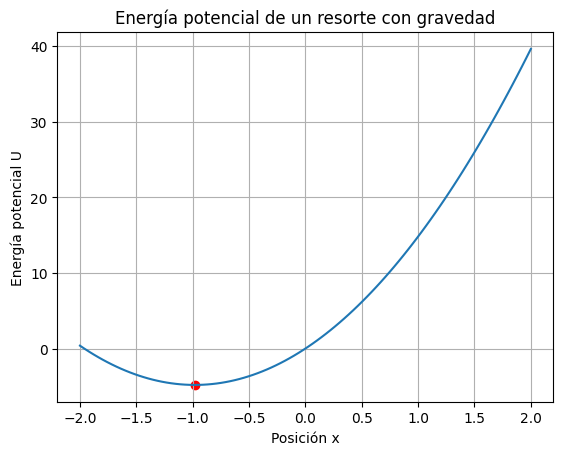

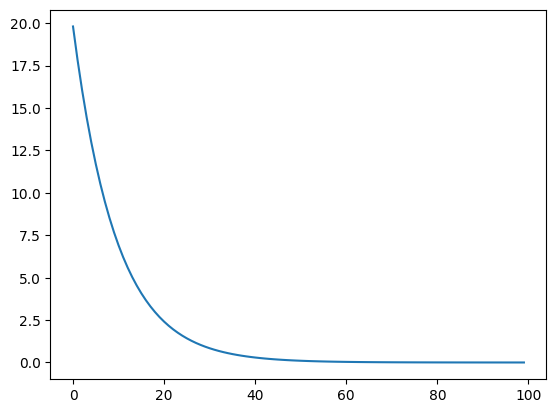

In [4]:
import torch
from torch import nn
import matplotlib.pyplot as plt
# TODO: definir x, k, m, g
x = torch.tensor(1.0, requires_grad=True)  # Posición inicial
k = 10.0  # Constante del resorte
m = 1.0   # Masa
g = 9.81  # Aceleración debido a la gravedad
# TODO: calcular U(x) y su gradiente con autograd
U = 0.5 * k * x**2 + m * g * x  # Energía potencial
U.backward()  # Calcula el gradiente dU/dx
print(f"Energía potencial U: {U.item():.4f}")
print(f"Gradiente dU/dx: {x.grad.item():.4f}")

# TODO: comparar con derivada analítica
dU_dx_analitico = k * x.item() + m * g  # Derivada analítica
print(f"Derivada analítica dU/dx: {dU_dx_analitico:.4f}")
# TODO: implementar descenso por el gradiente.
learning_rate = 0.01
grad_history = []
for i in range(100):
    x.grad = None  # Reiniciar el gradiente
    U = 0.5 * k * x**2 + m * g * x  # Recalcular la energía potencial
    U.backward()  # Calcular el gradiente
    with torch.no_grad():
        x -= learning_rate * x.grad  # Actualizar x usando el gradiente
    grad_history.append(x.grad.item())
print(f"Posición final x: {x.item():.4f}")
print(f"Energía potencial final U: {U.item():.4f}")

x_linspace = torch.linspace(-2, 2, 100)
U_values = 0.5 * k * x_linspace**2 + m * g * x_linspace
plt.plot(x_linspace.numpy(), U_values.numpy())
plt.scatter(x.item(), U.item(), color="red", label="Mínimo encontrado")
plt.xlabel("Posición x")
plt.ylabel("Energía potencial U")
plt.title("Energía potencial de un resorte con gravedad")
plt.grid()
plt.show()

plt.plot(grad_history)

## Ejercicio 2 — MLP de regresión para la deflexión de una viga

Desarrollar un modelo de regresión basado en una red neuronal (MLP) que estime la **deflexión máxima** de una viga simplemente apoyada sometida a una carga puntual.


![](https://uploads-cdn.omnicalculator.com/images/deflected/DEF1mod.png?width=150&enlarge=0&format=webp)

Según la teoría de vigas de Euler-Bernoulli [1](https://www.omnicalculator.com/es/construccion/deflexion-en-vigas), la deflexión máxima $\delta$ de una viga simplemente apoyada con una carga puntual $P$ aplicada en el centro está dada por:

$$
\delta = \frac{P L^3}{48 EI}
$$

donde:


* ( P ): carga aplicada (N)
* ( L ): longitud de la viga (m)
* ( E ): módulo de elasticidad del material (Pa)
* ( I ): momento de inercia de la sección (m$^4$)
* ( EI ): rigidez flexional

Para este ejercicio, se utilizará una versión simplificada y con ruido de esta relación. La base de datos se encuentra en `./data/beam_dataset.csv`, en donde se mide la deflexión máxima para distintos valores de $P$, $L$, $EI$.

1. Cargar los datos a partir del archivo csv `beam_dataset.csv`.
2. Entrenar un modelo de regresión basado en un **MLP (Multi-Layer Perceptron)** que prediga $\delta$ a partir de ( $P$, $L$, $EI$ ).

3. Calcular el **error medio absoluto (MAE)** sobre el conjunto de test. Graficar $ y_{\text{true}} $ vs $ y_{\text{pred}} $ y el error residual.

Early stopping en epoch 43
MAE en test (escala física de delta): 1.745411e-02


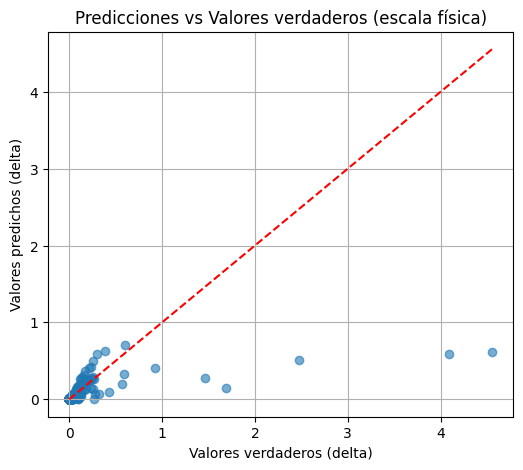

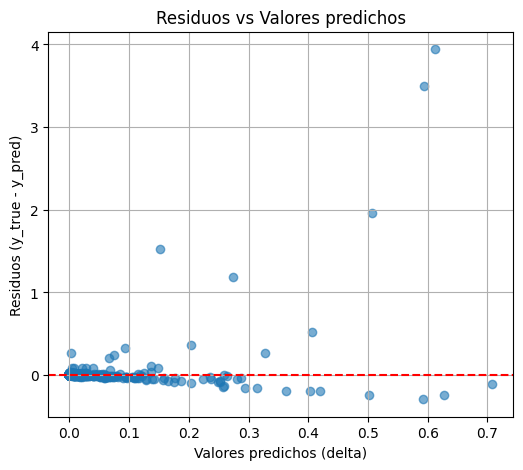

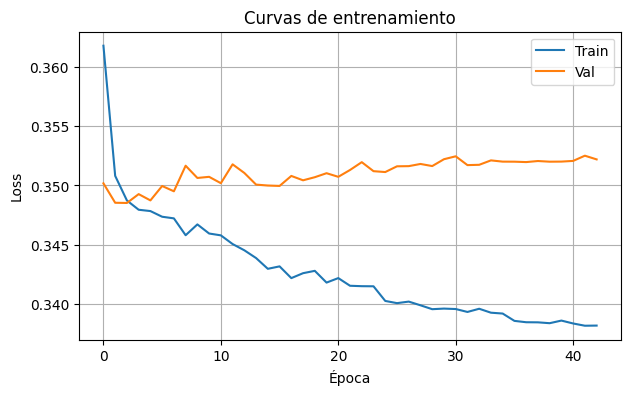

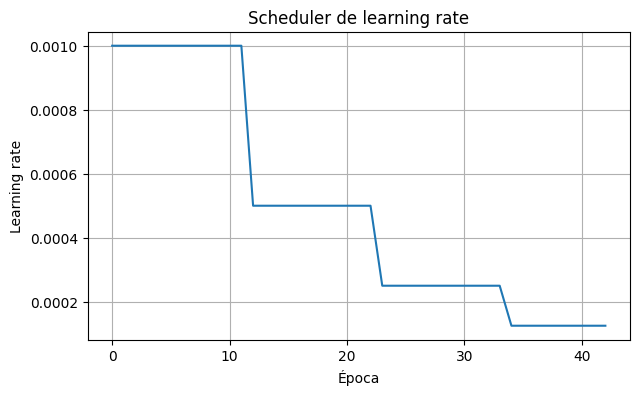

In [15]:
# Ejercicio 2 mejorado: log-espacio + split train/val/test + mini-batches + scheduler + ponderación de cola + early stopping
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

# 1) Carga de datos
df = pd.read_csv("data/beam_dataset.csv")
X = df[["P", "L", "EI"]].to_numpy(dtype=np.float32)
y = df["delta"].to_numpy(dtype=np.float32).reshape(-1, 1)

# 2) Transformación de objetivo a log-espacio (robusta a ceros)
eps = 1e-8
y_safe = np.clip(y, a_min=0.0, a_max=None) + eps
y_log = np.log(y_safe)

# 3) Split train/val/test (sin fuga de información)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_log, test_size=0.15, random_state=42
 )
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42
 )
# 0.1765 de 85% ≈ 15% del total

# 4) Estandarización usando solo estadísticas de train
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-8
y_mean = y_train.mean(axis=0, keepdims=True)
y_std = y_train.std(axis=0, keepdims=True) + 1e-8

X_train_n = (X_train - X_mean) / X_std
X_val_n = (X_val - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std

y_train_n = (y_train - y_mean) / y_std
y_val_n = (y_val - y_mean) / y_std
y_test_n = (y_test - y_mean) / y_std

# Pesos para enfatizar muestras con delta grande en el train
y_train_phys = np.exp(y_train) - eps
tail_scale = np.percentile(y_train_phys, 90) + 1e-8
sample_weights = 1.0 + 4.0 * (y_train_phys / tail_scale) ** 2
sample_weights = np.clip(sample_weights, 1.0, 25.0).astype(np.float32)

X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
X_val_t = torch.tensor(X_val_n, dtype=torch.float32)
X_test_t = torch.tensor(X_test_n, dtype=torch.float32)
y_train_t = torch.tensor(y_train_n, dtype=torch.float32)
y_val_t = torch.tensor(y_val_n, dtype=torch.float32)
y_test_t = torch.tensor(y_test_n, dtype=torch.float32)
sample_weights_t = torch.tensor(sample_weights, dtype=torch.float32)

# 5) DataLoader para mini-batches
batch_size = 32
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t, sample_weights_t), batch_size=batch_size, shuffle=True
 )
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False
 )
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False
 )

# 6) MLP de regresión
class MLP(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=X_train_t.shape[1], hidden_dim=64)
criterion = nn.SmoothL1Loss(reduction="none")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10, min_lr=1e-5
 )

def weighted_loss(prediction, target, weights):
    per_sample = criterion(prediction, target).mean(dim=1)
    return (per_sample * weights).sum() / weights.sum()

# 7) Entrenamiento con mini-batches, scheduler y early stopping
num_epochs = 600
patience = 40
best_val = float("inf")
best_state = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
train_losses, val_losses, lrs = [], [], []

for epoch in range(num_epochs):
    model.train()
    train_weighted_sum = 0.0
    train_unweighted_sum = 0.0
    train_count = 0

    for xb, yb, wb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = weighted_loss(pred, yb, wb)
        loss.backward()
        optimizer.step()

        batch_size_actual = xb.shape[0]
        train_weighted_sum += loss.item() * wb.sum().item()
        train_unweighted_sum += criterion(pred, yb).mean().item() * batch_size_actual
        train_count += batch_size_actual

    train_loss = train_unweighted_sum / train_count

    model.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            loss = criterion(pred, yb).mean()
            batch_size_actual = xb.shape[0]
            val_loss_sum += loss.item() * batch_size_actual
            val_count += batch_size_actual

    val_loss = val_loss_sum / val_count
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lrs.append(optimizer.param_groups[0]["lr"])

    if val_loss < best_val:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

    if epochs_no_improve >= patience:
        print(f"Early stopping en epoch {epoch+1}")
        break

model.load_state_dict(best_state)

# 8) Evaluación en test y desnormalización a escala física
model.eval()
preds_test = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds_test.append(model(xb))
y_pred_test_n = torch.cat(preds_test, dim=0)

# Volver de normalizado/log a unidades físicas de delta
y_pred_test_log = y_pred_test_n.numpy() * y_std + y_mean
y_test_log = y_test_t.numpy() * y_std + y_mean

y_pred_real = np.exp(y_pred_test_log) - eps
y_test_real = np.exp(y_test_log) - eps

# Evitar valores negativos por redondeo numérico
y_pred_real = np.clip(y_pred_real, a_min=0.0, a_max=None)
y_test_real = np.clip(y_test_real, a_min=0.0, a_max=None)

mae_real = np.mean(np.abs(y_pred_real - y_test_real))
print(f"MAE en test (escala física de delta): {mae_real:.6e}")

# 9) Gráficos
plt.figure(figsize=(6, 5))
plt.scatter(y_test_real, y_pred_real, alpha=0.6)
xy_min = min(y_test_real.min(), y_pred_real.min())
xy_max = max(y_test_real.max(), y_pred_real.max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], "r--")
plt.xlabel("Valores verdaderos (delta)")
plt.ylabel("Valores predichos (delta)")
plt.title("Predicciones vs Valores verdaderos (escala física)")
plt.grid(True)
plt.show()

residuos = y_test_real - y_pred_real
plt.figure(figsize=(6, 5))
plt.scatter(y_pred_real, residuos, alpha=0.6)
plt.axhline(0.0, color="r", linestyle="--")
plt.xlabel("Valores predichos (delta)")
plt.ylabel("Residuos (y_true - y_pred)")
plt.title("Residuos vs Valores predichos")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curvas de entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(lrs)
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.title("Scheduler de learning rate")
plt.grid(True)
plt.show()

## Ejercicio 3 — Clasificación de fases en Modelo Ising 2D

En este ejercicio se trabajará con un conjunto de datos generado a partir de simulaciones del **modelo de Ising bidimensional (2D)** utilizando métodos de Monte Carlo (algoritmo de Metropolis).

El modelo de Ising describe un sistema de espines en una red cuadrada, donde cada sitio puede tomar valores:

* (+1) (espín “arriba”)
* (-1) (espín “abajo”)

Los espines vecinos tienden a alinearse, pero la temperatura introduce fluctuaciones térmicas que pueden desordenar el sistema.

El comportamiento del sistema depende de la temperatura:

* **Temperatura baja $(T < T_c)$**:
  el sistema tiende a ordenarse, formando dominios grandes de espines alineados.

* **Temperatura alta $(T > T_c)$**:
  el sistema permanece desordenado debido a las fluctuaciones térmicas.

Existe una **temperatura crítica** conocida:

$$
T_c \approx 2.269
$$

en la cual ocurre una transición de fase entre el estado ordenado y desordenado.

Se provee un dataset compuesto por configuraciones del modelo de Ising. Los datos se encuentran en `.data/ising_dataset.pt`. Cada muestra corresponde a un vector de 625 elementos, que corresponden al aplanamiento de **imagen (grilla 2D)** $25\times 25$ de espines. Cada imagen fue generada a una cierta temperatura y tiene una etiqueta asociada a si se encuentra por encima o por debajo de $T_C$:

  * $y = 0$: temperatura **por debajo** de $T_c$
  * $y = 1$: temperatura **por encima** de $T_c$


Entrenar un modelo de clasificación supervisada que, dada una configuración del sistema, sea capaz de predecir si corresponde a:

* fase ordenada ((T < T_c))
* fase desordenada ((T > T_c))

utilizando un perceptrón multicapa (MLP) utilizando el vector de datos provisto y una red neuronal convolucional (CNN) transformando el vector en un arreglo de 2 dimensiones (imagen). Para esto, utilizar una función de pérdida adecuada para clasificación binaria. Comparar los resultados entre ambas arquitecturas comparando la **accuracy** en cada caso.


In [19]:
import torch
from torch import nn
# cargar datos de ising_dataset.pt 
data = torch.load("data/ising_dataset.pt")

In [20]:
print(data.keys())

dict_keys(['X_train', 'y_train', 'X_test', 'y_test'])


In [98]:
# Definición del perceptrón multicapa para clasificación binaria
class MLP(nn.Module):
    def __init__(self, input_dim=625, hidden_N=32, hidden_L=3):
        super().__init__()

        # Construimos dinámicamente las capas en una lista
        layers = []

        # Primera capa: de la entrada (625 features) a la capa oculta
        layers.append(nn.Linear(input_dim, hidden_N))
        layers.append(nn.ReLU())

        # Capas ocultas adicionales (hidden_L - 1)
        for _ in range(hidden_L - 1):
            layers.append(nn.Linear(hidden_N, hidden_N))
            layers.append(nn.ReLU())

        # Capa de salida: 1 neurona para probabilidad de clase positiva
        layers.append(nn.Linear(hidden_N, 1))
        layers.append(nn.Sigmoid())  # convierte salida a rango [0,1]

        # Empaquetamos todo como una red secuencial
        self.net = nn.Sequential(*layers)

    # Forward: define cómo fluye x por la red
    def forward(self, x):
        return self.net(x)


# -------------------- Entrenamiento --------------------

# Instanciamos el modelo con arquitectura elegida
model = MLP(input_dim=data["X_train"].shape[1], hidden_N=64, hidden_L=3)

# Función de pérdida para clasificación binaria con salida sigmoide
criterion = nn.BCELoss()

# Optimizador Adam para actualizar parámetros de la red
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Máximo de épocas de entrenamiento
num_epochs = 500

# Historial para graficar evolución de pérdidas
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # ----- Modo entrenamiento -----
    model.train()               # activa comportamiento de entrenamiento
    optimizer.zero_grad()       # limpia gradientes acumulados

    # Predicción sobre conjunto de entrenamiento
    outputs = model(data["X_train"])

    # Cálculo de pérdida train
    loss = criterion(outputs, data["y_train"])

    # Backpropagation
    loss.backward()

    # Paso de optimización (actualiza pesos)
    optimizer.step()

    # Guardamos pérdida de train
    train_losses.append(loss.item())

    # Log cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

    # ----- Modo evaluación (sin gradientes) -----
    model.eval()
    with torch.no_grad():
        # Predicción y pérdida en test
        test_outputs = model(data["X_test"])
        test_loss = criterion(test_outputs, data["y_test"])
        test_losses.append(test_loss.item())

    # Early stopping simple:
    # si la pérdida de test sube respecto a la época anterior, frenamos
    if len(test_losses) > 1 and test_losses[-1] > test_losses[-2]:
        print(
            f"Early stopping en epoch {epoch+1}: test loss subió "
            f"de {test_losses[-2]:.4f} a {test_losses[-1]:.4f}"
        )
        break

Epoch [10/500], Loss: 0.6179
Epoch [20/500], Loss: 0.4152
Epoch [30/500], Loss: 0.1408
Early stopping en epoch 32: test loss subió de 0.4125 a 0.4130


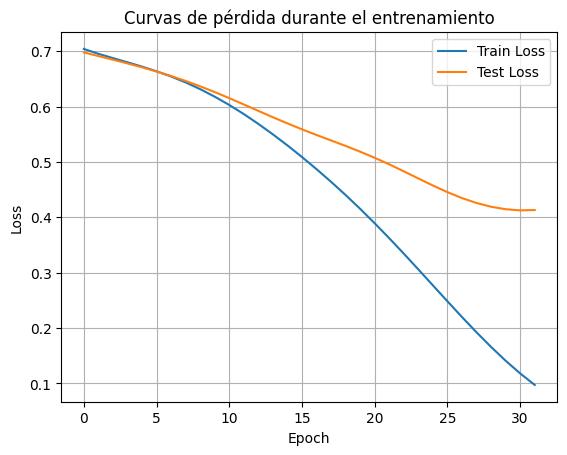

In [99]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de pérdida durante el entrenamiento")
plt.legend()
plt.grid()
plt.show()

In [82]:
import copy
import torch
from torch import nn

if "data" not in globals():
    data = torch.load("data/ising_dataset.pt")

class MLP(nn.Module):
    def __init__(self, input_dim=625, hidden_N=32, hidden_L=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_N))
        layers.append(nn.ReLU())
        for _ in range(hidden_L - 1):
            layers.append(nn.Linear(hidden_N, hidden_N))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_N, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Búsqueda simple de hiperparámetros para la arquitectura del MLP.
hidden_N_grid = [32, 64, 128, 256, 525, 1028]
hidden_L_grid = [1, 2, 3, 4]

num_epochs = 250
patience = 20
criterion = nn.BCELoss()

best_cfg = None
best_test_loss = float("inf")
best_state = None
best_train_losses = None
best_test_losses = None

for hidden_N in hidden_N_grid:
    for hidden_L in hidden_L_grid:
        torch.manual_seed(42)
        candidate = MLP(
            input_dim=data["X_train"].shape[1],
            hidden_N=hidden_N,
            hidden_L=hidden_L,
        )
        optimizer = torch.optim.Adam(candidate.parameters(), lr=1e-3)

        train_losses_cfg = []
        test_losses_cfg = []
        best_cfg_loss = float("inf")
        best_cfg_state = None
        no_improve = 0

        for epoch in range(num_epochs):
            candidate.train()
            optimizer.zero_grad()
            outputs = candidate(data["X_train"])
            train_loss = criterion(outputs, data["y_train"])
            train_loss.backward()
            optimizer.step()

            candidate.eval()
            with torch.no_grad():
                test_outputs = candidate(data["X_test"])
                test_loss = criterion(test_outputs, data["y_test"])

            train_losses_cfg.append(train_loss.item())
            test_losses_cfg.append(test_loss.item())

            if test_loss.item() < best_cfg_loss - 1e-6:
                best_cfg_loss = test_loss.item()
                best_cfg_state = copy.deepcopy(candidate.state_dict())
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= patience:
                break

        print(
            f"hidden_N={hidden_N:>3}, hidden_L={hidden_L}: "
            f"best_test_loss={best_cfg_loss:.4f}, epochs={len(test_losses_cfg)}"
        )

        if best_cfg_loss < best_test_loss:
            best_test_loss = best_cfg_loss
            best_cfg = {"hidden_N": hidden_N, "hidden_L": hidden_L}
            best_state = best_cfg_state
            best_train_losses = train_losses_cfg
            best_test_losses = test_losses_cfg

# Reconstruimos el mejor modelo para que la celda siguiente de accuracy lo use.
model = MLP(
    input_dim=data["X_train"].shape[1],
    hidden_N=best_cfg["hidden_N"],
    hidden_L=best_cfg["hidden_L"],
)
model.load_state_dict(best_state)

train_losses = best_train_losses
test_losses = best_test_losses

print("\nMejor configuración encontrada:", best_cfg)
print(f"Mejor test loss: {best_test_loss:.4f}")

hidden_N= 32, hidden_L=1: best_test_loss=0.5161, epochs=61
hidden_N= 32, hidden_L=2: best_test_loss=0.4127, epochs=74
hidden_N= 32, hidden_L=3: best_test_loss=0.4854, epochs=66
hidden_N= 32, hidden_L=4: best_test_loss=0.4385, epochs=66
hidden_N= 64, hidden_L=1: best_test_loss=0.5074, epochs=50
hidden_N= 64, hidden_L=2: best_test_loss=0.3828, epochs=53
hidden_N= 64, hidden_L=3: best_test_loss=0.3884, epochs=50
hidden_N= 64, hidden_L=4: best_test_loss=0.3884, epochs=48
hidden_N=128, hidden_L=1: best_test_loss=0.4615, epochs=45
hidden_N=128, hidden_L=2: best_test_loss=0.3225, epochs=43
hidden_N=128, hidden_L=3: best_test_loss=0.3060, epochs=40
hidden_N=128, hidden_L=4: best_test_loss=0.2754, epochs=38
hidden_N=256, hidden_L=1: best_test_loss=0.4085, epochs=40
hidden_N=256, hidden_L=2: best_test_loss=0.2788, epochs=36
hidden_N=256, hidden_L=3: best_test_loss=0.2356, epochs=33
hidden_N=256, hidden_L=4: best_test_loss=0.2039, epochs=32
hidden_N=525, hidden_L=1: best_test_loss=0.3455, epochs=

In [95]:
# Defino una red convolucional simple para clasificación binaria en el dataset de Ising.
class CNN(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=16, num_classes=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(input_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 25x25 -> 12x12
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 12x12 -> 6x6
            nn.Flatten(),
            nn.Linear((hidden_channels * 2) * 6 * 6, num_classes),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

In [96]:
# Entrenar el modelo CNN con la misma configuración de entrenamiento que el MLP.
cnn = CNN()
optimizer_cnn = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion_cnn = nn.BCELoss()

# Reorganizo los vectores planos (625) a imágenes 25x25 con 1 canal: [N, 1, 25, 25].
X_train_img = data["X_train"].view(-1, 1, 25, 25)
X_test_img = data["X_test"].view(-1, 1, 25, 25)

# Entrenamiento del CNN (similar al MLP pero adaptado a la entrada 2D)
num_epochs_cnn = 250
train_losses_cnn = []
test_losses_cnn = []
for epoch in range(num_epochs_cnn):
    cnn.train()
    optimizer_cnn.zero_grad()
    outputs = cnn(X_train_img)
    train_loss = criterion_cnn(outputs, data["y_train"])
    train_loss.backward()
    optimizer_cnn.step()

    cnn.eval()
    with torch.no_grad():
        test_outputs = cnn(X_test_img)
        test_loss = criterion_cnn(test_outputs, data["y_test"])

    train_losses_cnn.append(train_loss.item())
    test_losses_cnn.append(test_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"CNN Epoch [{epoch+1}/{num_epochs_cnn}] | "
            f"Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}"
        )

    # Agregamos early stopping simple para el CNN
    if epoch > 20 and test_losses_cnn[-1] > min(test_losses_cnn[-20:]):
        print(f"CNN Early stopping en epoch {epoch+1}")
        break

CNN Epoch [10/250] | Train Loss: 0.4155 | Test Loss: 0.3778
CNN Epoch [20/250] | Train Loss: 0.1297 | Test Loss: 0.1132
CNN Epoch [30/250] | Train Loss: 0.0590 | Test Loss: 0.0550
CNN Epoch [40/250] | Train Loss: 0.0470 | Test Loss: 0.0438
CNN Epoch [50/250] | Train Loss: 0.0421 | Test Loss: 0.0405
CNN Epoch [60/250] | Train Loss: 0.0383 | Test Loss: 0.0393
CNN Early stopping en epoch 69


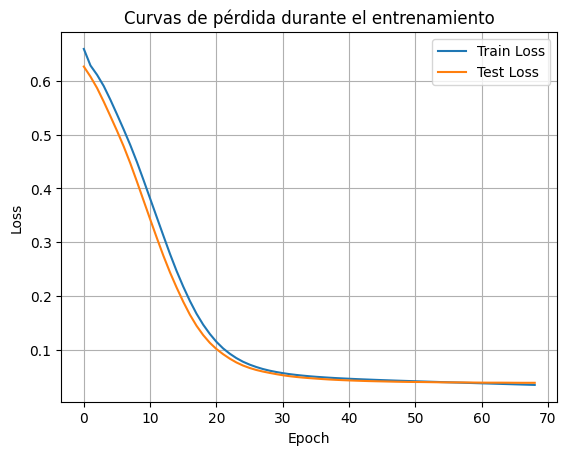

In [97]:
import matplotlib.pyplot as plt
plt.plot(train_losses_cnn, label="Train Loss")
plt.plot(test_losses_cnn, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curvas de pérdida durante el entrenamiento")
plt.legend()
plt.grid()
plt.show()

In [100]:

# TODO: calcular accuracy 
def calculate_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        predicted = (outputs >= 0.5).float()
        correct = (predicted == y).sum().item()
        total = y.size(0)
    return correct / total

train_acc = calculate_accuracy(model, data["X_train"], data["y_train"])
test_acc = calculate_accuracy(model, data["X_test"], data["y_test"])
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

cnn_train_acc = calculate_accuracy(cnn, X_train_img, data["y_train"])
cnn_test_acc = calculate_accuracy(cnn, X_test_img, data["y_test"])
print(f"CNN Train Accuracy: {cnn_train_acc:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

Train Accuracy: 1.0000
Test Accuracy: 0.8050
CNN Train Accuracy: 0.9838
CNN Test Accuracy: 0.9850


---

## Ejercicio 4 — Gradiente por diferencias finitas vs backprop

Antes de usar restricciones físicas conviene verificar que entendemos cómo se propagan los gradientes. En este ejercicio vas a comparar dos formas de estimar la derivada de una función de costo respecto de un parámetro.

- Definir una red pequeña y una función de pérdida simple.
- Calcular el gradiente con `backward()` e imprimir el gradiente de un parámetro a elección del modelo. Para acceder a los gradientes de los pesos de la capa $i$ del modelo se puede usar `model[i].weight.grad`.
- Aproximar ese mismo gradiente mediante diferencias finitas. Para esto, vamos a aproximar $\partial f_w(x) / \partial w_i \approx (f_{w_i+\epsilon}(x)-f_{w_i-\epsilon}(x))/(2\epsilon)$. consejo: utilizar `with torch.no_grad` para no trackear los cambios manuales en los parámetros en el grafo. 
- Comparar ambos valores y comentar si la diferencia es pequeña.

In [ ]:
# TODO: definir una red pequeña y una loss
# TODO: calcular gradiente por backward
# TODO: aproximar el gradiente por diferencias finitas
# TODO: comparar ambos valores

---

## Ejercicio 5 — Positividad de un coeficiente físico

Muchos parámetros físicos no pueden tomar cualquier valor. Por ejemplo, un coeficiente de difusión o un amortiguamiento deben ser positivos. Si el modelo predice valores negativos, el ajuste puede ser numéricamente correcto pero físicamente inválido.

Generaremos un dataset sintético donde el coeficiente objetivo deba ser siempre positivo.

- Entrenar un modelo con salida libre.
- Entrenar otro modelo que garantice positividad usando `softplus` en la salida.
- Comparar predicciones y detectar si el modelo libre produce valores sin sentido físico.

In [19]:
import torch
from torch import nn
# Barajar las filas de T
T = torch.linspace(300, 900, 300).view(-1, 1)
perm = torch.randperm(T.size(0))
T = T[perm]
def generador_de_datos(T):
    return 0.05 + 0.0002 * (T - 300) + 0.005 * torch.rand_like(T)


# TODO: entrenar un modelo libre y otro con salida softplus
class MLP_Softplus(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),  # Asegura salida positiva
        )

    def forward(self, x):
        return self.net(x)
    
class MLP_Libre(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),  # Sin restricción de salida
        )

    def forward(self, x):
        return self.net(x)

def train_model(model, T, y, num_epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loss_history = []
    print(f"Entrenando modelo: {model.__class__.__name__}")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(T)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {loss.item():.6f}")
    return model

T_train = T[:270]
y_train = generador_de_datos(T_train)
T_test = T[270:300]
y_test = generador_de_datos(T_test)

# Normalización usando solo estadísticas de train para evitar fuga de información
T_mean = T_train.mean(dim=0, keepdim=True)
T_std = T_train.std(dim=0, keepdim=True) + 1e-8
T_train_n = (T_train - T_mean) / T_std
T_test_n = (T_test - T_mean) / T_std

model_softplus = MLP_Softplus()
model_libre = MLP_Libre()
model_softplus = train_model(model_softplus, T_train_n, y_train)
model_libre = train_model(model_libre, T_train_n, y_train)
# TODO: comparar si aparecen valores no físicos
with torch.no_grad():
    pred_softplus = model_softplus(T_test_n)
    pred_libre = model_libre(T_test_n)
    print("Predicciones MLP Softplus:", pred_softplus.squeeze().numpy())
    print("Predicciones MLP Libre:", pred_libre.squeeze().numpy())

Entrenando modelo: MLP_Softplus
Epoch [50/50] | Loss: 0.055750
Entrenando modelo: MLP_Libre
Epoch [50/50] | Loss: 0.008736
Predicciones MLP Softplus: [0.43543378 0.19492033 0.20124897 0.37513626 0.4287826  0.39926216
 0.29348415 0.41343156 0.43233243 0.36561385 0.41192117 0.20776248
 0.40221196 0.43563506 0.42722723 0.23584239 0.4311899  0.21446514
 0.43351266 0.21904062 0.3642699  0.23794217 0.26329467 0.433269
 0.38767868 0.3602629  0.26676852 0.25872436 0.40993735 0.4132357 ]
Predicciones MLP Libre: [ 0.02192889  0.07107469  0.06517367 -0.00319394  0.05483204  0.10464068
  0.00506144  0.08043727  0.00664216  0.0003228   0.082985    0.05924091
  0.09954523  0.01747037  0.05746056  0.02722605  0.00562904  0.05183661
  0.04168972  0.04690044  0.0008582   0.02471418  0.01133328  0.00765529
 -0.00455283  0.00246437  0.01102966  0.01199007 -0.00584565 -0.00498946]


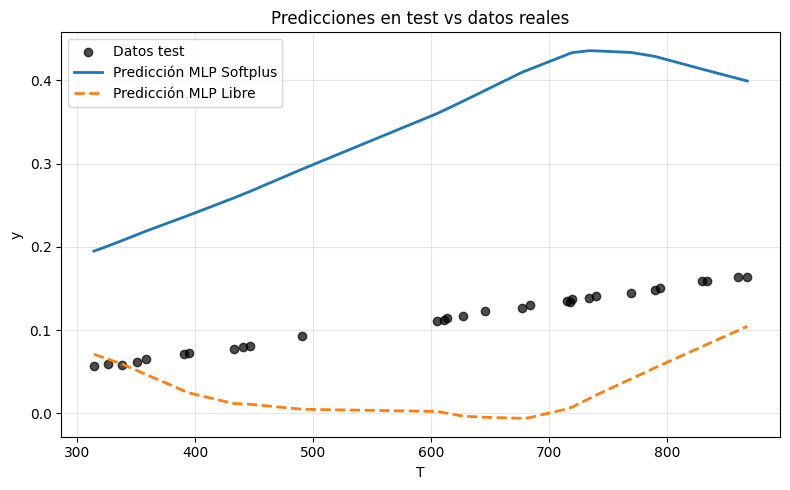

In [20]:
import matplotlib.pyplot as plt

# Ordenar el conjunto de test para que las curvas se vean continuas en el gráfico
sort_idx = torch.argsort(T_test.squeeze())
T_test_sorted = T_test[sort_idx]
y_test_sorted = y_test[sort_idx]

# Aplicar la misma normalización del entrenamiento antes de inferir
T_test_sorted_n = (T_test_sorted - T_mean) / T_std

with torch.no_grad():
    pred_softplus_test = model_softplus(T_test_sorted_n)
    pred_libre_test = model_libre(T_test_sorted_n)

plt.figure(figsize=(8, 5))
plt.scatter(
    T_test_sorted.squeeze().cpu().numpy(),
    y_test_sorted.squeeze().cpu().numpy(),
    color="black",
    alpha=0.7,
    label="Datos test",
)
plt.plot(
    T_test_sorted.squeeze().cpu().numpy(),
    pred_softplus_test.squeeze().cpu().numpy(),
    color="tab:blue",
    linewidth=2,
    label="Predicción MLP Softplus",
)
plt.plot(
    T_test_sorted.squeeze().cpu().numpy(),
    pred_libre_test.squeeze().cpu().numpy(),
    color="tab:orange",
    linewidth=2,
    linestyle="--",
    label="Predicción MLP Libre",
)

plt.xlabel("T")
plt.ylabel("y")
plt.title("Predicciones en test vs datos reales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Ejercicio 6 — Penalización física por constraint

En muchos sistemas físicos no solo importa el valor predicho, sino también cómo cambia respecto a las variables de entrada. Por ejemplo, en flujo en tuberías, la caída de presión debe ser una función creciente del caudal.

- Verificar que el código presentado para la generación de datos genere datos de la forma $\Delta P \propto \frac{Q^2}{D^5}$
- Definir una red cuyo objetivo sea predecir el logaritmo de la caída de presión ($\log \Delta P$) en función del logaritmo del caudal $\log Q$ y el logaritmo del diámetro $\log D$.
- Utilizar autograd para calcular la derivada de la predicción respecto de las entradas.
- Agregar una penalización que castigue regiones donde `dP/dQ < 0` (para esto tener en cuenta la desnormalización y la transformada inversa del logaritmo).
- Entrenar con pérdida total = pérdida de datos + cte * penalización física (inclusión de sesgo inductivo).

ratio mean (esperado ~10.0): 10.000000
ratio std: 5.038912e-06
Epoch   10 | Total: 0.811502 | Data: 0.811502 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   20 | Total: 0.685558 | Data: 0.685558 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   30 | Total: 0.543765 | Data: 0.543765 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   40 | Total: 0.402047 | Data: 0.402047 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   50 | Total: 0.277076 | Data: 0.277076 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   60 | Total: 0.180302 | Data: 0.180302 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   70 | Total: 0.115568 | Data: 0.115568 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   80 | Total: 0.077970 | Data: 0.077970 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch   90 | Total: 0.058437 | Data: 0.058437 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch  100 | Total: 0.049079 | Data: 0.049079 | Phys: 0.000000 | Frac viol (batch): 0.000
Epoch  110 | Total: 0.044406 | Data: 

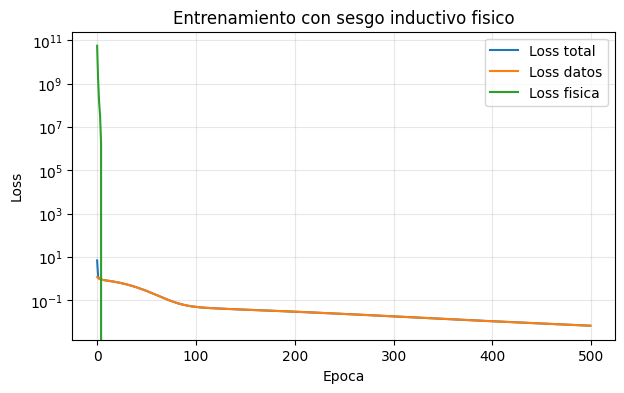

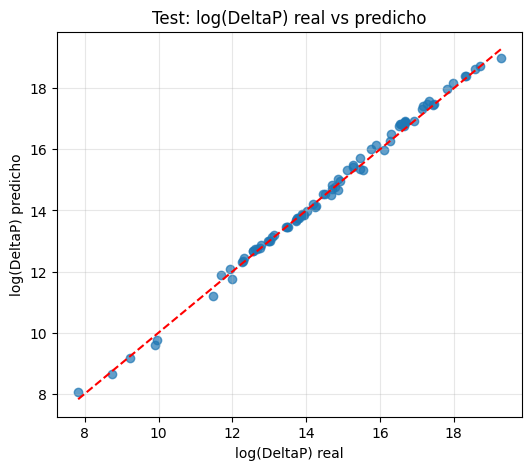

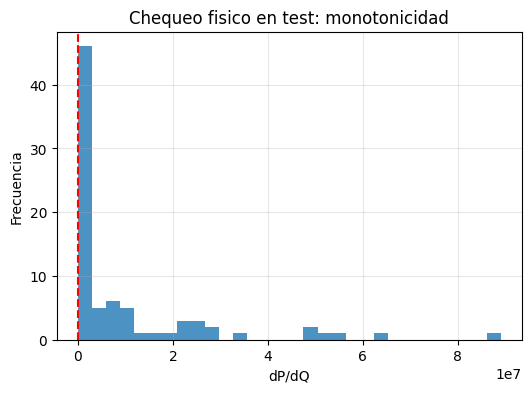

In [48]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# Reproducibilidad
# torch.manual_seed(42)

eps = 1e-8
N = 400

# =========================
# 1) Generacion de datos y verificacion fisica
# =========================
Q = torch.rand(N, 1) * 5.0                      # Caudal
D = 0.05 + 0.15 * torch.rand(N, 1)              # Diametro
cte = 10.0

deltaP_clean = cte * Q**2 / D**5                # DeltaP ~ Q^2 / D^5
ratio = deltaP_clean * D**5 / (Q**2 + eps)      # Debe ser ~ cte

print(f"ratio mean (esperado ~{cte}): {ratio.mean().item():.6f}")
print(f"ratio std: {ratio.std().item():.6e}")

# Objetivo: log(DeltaP) con ruido
y_log = torch.log(deltaP_clean + eps) + 0.01 * torch.randn_like(Q)

# Features pedidas: [log Q, log D]
X = torch.cat([torch.log(Q + eps), torch.log(D)], dim=1)

# =========================
# 2) Split + normalizacion (solo estadisticas de train)
# =========================
perm = torch.randperm(N)
n_train = int(0.8 * N)
idx_train, idx_test = perm[:n_train], perm[n_train:]

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y_log[idx_train], y_log[idx_test]

X_mean = X_train.mean(0, keepdim=True)
X_std = X_train.std(0, keepdim=True) + 1e-8
y_mean = y_train.mean(0, keepdim=True)
y_std = y_train.std(0, keepdim=True) + 1e-8

X_train_n = (X_train - X_mean) / X_std
X_test_n = (X_test - X_mean) / X_std
y_train_n = (y_train - y_mean) / y_std
y_test_n = (y_test - y_mean) / y_std

train_loader = DataLoader(TensorDataset(X_train_n, y_train_n), batch_size=64, shuffle=True)

# =========================
# 3) Red para predecir log(DeltaP)
# =========================
class LogDeltaPNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

model = LogDeltaPNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# =========================
# 4) Penalizacion fisica: castigar dP/dQ < 0
# =========================
def physical_penalty(model, Xn_batch, X_mean, X_std, y_mean, y_std, eps=1e-8):
    Xn_req = Xn_batch.clone().detach().requires_grad_(True)

    # Prediccion normalizada de log(DeltaP)
    y_pred_n = model(Xn_req)

    # Desnormalizar a log(DeltaP) fisico
    y_pred_log = y_pred_n * y_std + y_mean

    # Gradiente de log(DeltaP) respecto de entradas normalizadas
    grads = torch.autograd.grad(
        outputs=y_pred_log.sum(),
        inputs=Xn_req,
        create_graph=True,
    )[0]

    # d(logP)/d(logQ) considerando normalizacion de entrada
    dlogP_dlogQ = grads[:, 0:1] / X_std[:, 0:1]

    # Reconstruccion fisica
    logQ = Xn_req[:, 0:1] * X_std[:, 0:1] + X_mean[:, 0:1]
    Q_phys = torch.exp(logQ)
    P_phys = torch.exp(y_pred_log)

    # dP/dQ = (P/Q) * d(logP)/d(logQ)
    dP_dQ = (P_phys / (Q_phys + eps)) * dlogP_dlogQ

    # Penalizar solo regiones no fisicas
    pen = torch.relu(-dP_dQ).pow(2).mean()
    frac_viol = (dP_dQ < 0).float().mean()
    return pen, dP_dQ, frac_viol

# =========================
# 5) Entrenamiento: loss_total = loss_datos + lambda * loss_fisica
# =========================
lambda_phys = 1e-10
epochs = 500
train_hist, data_hist, phys_hist = [], [], []

for epoch in range(epochs):
    model.train()
    epoch_total, epoch_data, epoch_phys = 0.0, 0.0, 0.0
    nb = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        pred_n = model(xb)
        loss_data = criterion(pred_n, yb)

        loss_phys, _, frac_viol_train = physical_penalty(
            model, xb, X_mean, X_std, y_mean, y_std, eps=eps
        )

        loss_total = loss_data + lambda_phys * loss_phys
        loss_total.backward()
        optimizer.step()

        epoch_total += loss_total.item()
        epoch_data += loss_data.item()
        epoch_phys += loss_phys.item()
        nb += 1

    train_hist.append(epoch_total / nb)
    data_hist.append(epoch_data / nb)
    phys_hist.append(epoch_phys / nb)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:4d} | Total: {train_hist[-1]:.6f} | "
            f"Data: {data_hist[-1]:.6f} | Phys: {phys_hist[-1]:.6f} | "
            f"Frac viol (batch): {frac_viol_train.item():.3f}"
        )

# =========================
# 6) Evaluacion en test
# =========================
model.eval()
with torch.no_grad():
    pred_test_n = model(X_test_n)
    test_data_loss = criterion(pred_test_n, y_test_n).item()
    pred_test_log = pred_test_n * y_std + y_mean

loss_phys_test, dP_dQ_test, frac_viol_test = physical_penalty(
    model, X_test_n, X_mean, X_std, y_mean, y_std, eps=eps
)

print(f"\nTest data loss (MSE en y normalizado): {test_data_loss:.6f}")
print(f"Test physics penalty: {loss_phys_test.item():.6e}")
print(f"Fraccion test con dP/dQ < 0: {frac_viol_test.item()*100:.2f}%")
print("Primeros 10 valores de dP/dQ en test:")
print(dP_dQ_test[:10].detach().squeeze().cpu().numpy())

# =========================
# 7) Graficos
# =========================
plt.figure(figsize=(7, 4))
plt.plot(train_hist, label="Loss total")
plt.plot(data_hist, label="Loss datos")
plt.semilogy(phys_hist, label="Loss fisica")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Entrenamiento con sesgo inductivo fisico")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(y_test.squeeze().cpu().numpy(), pred_test_log.squeeze().detach().cpu().numpy(), alpha=0.7)
mn = min(y_test.min().item(), pred_test_log.min().item())
mx = max(y_test.max().item(), pred_test_log.max().item())
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("log(DeltaP) real")
plt.ylabel("log(DeltaP) predicho")
plt.title("Test: log(DeltaP) real vs predicho")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(dP_dQ_test.detach().cpu().numpy(), bins=30, alpha=0.8)
plt.axvline(0.0, color="r", linestyle="--")
plt.xlabel("dP/dQ")
plt.ylabel("Frecuencia")
plt.title("Chequeo fisico en test: monotonicidad")
plt.grid(True, alpha=0.3)
plt.show()